# CC3104 – Aprendizaje por Refuerzo

# Laboratorio 3

Francis Aguilar, 22243

César López, 22535

José Marchena, 22398

## Instrucciones

Una empresa de desarrollo de videojuegos está evaluando el uso de agentes de RL para generar comportamiento no determinista en personajes de un juego de rol táctico. El entorno de prueba es un mapa de cuadrícula de **6 × 6** con zonas de recompensa, zonas de penalización y un estado terminal.

El equipo técnico necesita entender si Monte Carlo es viable para este dominio antes de escalar a métodos más complejos, y quiere comparar su comportamiento contra la línea base de **Programación Dinámica** de la semana anterior.

Su grupo ha sido contratado para diseñar el experimento, implementar los métodos, analizar los resultados y producir un reporte técnico con recomendaciones sobre la viabilidad de Monte Carlo para este dominio.

---


# Task 1 (Entrega Parcial)

Antes de implementar nada, diseñen formalmente el experimento que van a ejecutar. El diseño debe incluir:

## 1. **Especificación del MDP:**

**Definan el espacio de estados, el espacio de acciones, la función de recompensa y el factor de descuento $\gamma$ para el mapa 6 × 6. Justifiquen cada decisión de diseño.**
El mapa debe incluir al menos:

- Dos zonas de recompensa positiva.
- Una zona de penalización.
- Un estado terminal.

La función de recompensa debe capturar al menos dos objetivos potencialmente conflictivos propios del dominio de videojuegos.

### Mapa propuesto:

| `Inicio` | .          | .   | .   | .              | .          |
| -------- | ---------- | --- | --- | -------------- | ---------- |
| .        | .          | .   | .   | .              | .          |
| .        | .          | .   | .   | .              | .          |
| .        | .          | .   | .   | `Penalizacion` | `Objetivo` |
| .        | .          | .   | .   | .              | .          |
| .        | `Objetivo` | .   | .   | .              | `Terminal` |

### Estado:

- X, Y: coordenada de la celda donde se encuentra el agente (0-5)
- $v_i$: Representativo de las celdeas de recompenza $i$ y determina si ya fueron visitadas o no, es decir, si la recompenza ya ha sido capturada
  $\mathcal(S)=(x,y,v1)$
  Donde
  $x,y \in {0,1,..,5}$
  $vi \in {0,1}$

### Acciones:

- Movimiento: (`arriba`,`abajo`,`izquierda`,`derecha`)
  $A = {\mathcal(arriba)},\mathcal(abajo),\mathcal(izquierda),\mathcal(derecha)$

Con desplazamientos $\delta = {(0,-1),(0,1),(-1,0),(0,-1)}$

### Transición: $P(s' | s,a)$

Determinsta.

- Bordes: no puede moverse a los bordes y las transiciones inposibles se eliminan.
- Estado terminal: absorbente

### Recompenza: $R(s,a,s')$

- El estado terminal debe tener alta recompenza para asegurar que el agente logre llegar a este destino. $+100 si s' = terminal$
- Los estados de recompenza deben sumar menos del estado final, esto asegura que incluso sin recompenza, el modelo logre llegar al final pero que de igual forma busque recompenzas. $+5 si s' v_i = 0, es la primera visita$
- Penalizacion debe ser mayor a la de las zonas de recompenza, de esta manera el agente evita estos estados sin entrar en un bucle de recompenza. $-15 si s' \in {penalizacion}$
- Cada transición tiene un costo pequeño, pero indeseable para el agente. $-1 cualquier otro caso$

Esto cumple las restricciones
$R_{terminal} > \sum_{i}^{} R_{r_i}:100) > 5+5 = 10$ (se llega al final aunque se ignore la recompenza)

$R_{penalziacion} > R_{r_i}:15 > 5$ (evita penalizacion aunque eso signifique perder una recompenza)

### Factor de descuento

$\gamma = 0.99$

$\gamma$ cercano a 1 hace que el agente valore recompensas lejanas casi tanto como inmediatas, necesario cuando el camino óptimo (recolectar ambas recompensas y evitar ambas penalizaciones) requiere planificación a varios pasos.

## 2. **Selección de variante Monte Carlo:**

**Argumenten cuál variante usarán (First-Visit o Every-Visit) y por qué es más apropiada para este dominio específico. Incluyan en su argumento una discusión sobre la frecuencia esperada de revisitas a estados en un mapa 6 × 6 bajo una política aleatoria.**

Eleccion: First Visit
Para un estado es en el estimador de valor por montegarlo, G*t considera solo la primera vez que aparece s en cada episodio.
$V(s) \approx \frac{1}{N(s)} \sum*{i=1}^{N(s)} G_i(s)$

Se prefiere esto para nuestro caso, pues nos da independencia de las muestras lo cual nos ayuda a converger más rapido al introducir menos sesgo.

También, dado que tenemos un bajo dominio dde $|S| = 6 \times 6 = 144$ la probabilidad de caer nuevamente en una misma casilla es alta, lo cual inflaria la cantidad de muestras correlacionadas de Every-Visit haciendolo menos deseable.

## 3. **Estrategia de exploración:**

**Argumenten si usarán Exploring Starts o una política $\epsilon$-soft.Justifiquen su elección considerando si en el dominio de videojuegos es razonable controlar el estado inicial del agente. Propongan un valor concreto de $\epsilon$ si eligen política $\epsilon$-soft, con justificación.**

Elección: $\epsilon$-soft.
Uno de los casos de uso mas importantes para Exploring Starts, es la idea que el inicio no sea importante o que un agente pueda "teletransportarse" entre tuplas (s,a). En el caso del dominio de videojuegos, esto no es del todo razonable.

Un personaje en un RPG tácico tendrá una posición fija de inicio por cuestiones de diseño de nivel o narrativa. Por lo que forzar inicios arbitrarios, no hace del todo sentido porque podrian haber circunstancias imposibles que se simulen. Aunque esto no descarta ES por completo, igual no es un sistema escalable si se expande el dominio del videojuego.

Por tanto, se opta por una politica $\epsilon$-greedy con caso particular $\epsilon$-soft, que garantiza que $\pi(a|b) \ge \frac{\epsilon}{|A|}$ para toda acción, manteniendo el inicio del episodio fijo y delegando exploracion a la aleatoreidad.

Asimismo se propone un valor de $\epsilon = 0.1$ al ser el estandar que cumple estas condiciones, que nos indica que caa acción suboptima tiene 0.025 minimo de probabilidad de ser tomada.

## 4. **Hipótesis de comparación:**

**Antes de ejecutar el experimento, formulen al menos dos hipótesis concretas sobre cómo esperan que se comporte Monte Carlo en comparación con Value Iteration de la semana pasada. Las hipótesis deben ser falsables y cuantificables.**

- H1: Convergencia
  Tras un $N = 5000$ episodios de entrenamiento, la política $\pi_{mc}$ convergerá a un valor promedio $V^{\pi_MC}(s_0)$ que se ubicara dentro de 5% del valor óptimo de $V^*(s_0)$ bajo DP. Asimismo, la varianza de corridas independientes con 10 semillas distintas de MC debe ser considerablemente mayor que DP.

Es falsable y cuantificable por el 5%.

- H2: Costo Computacional
  Monte Carlo First-Visit convergerá al menos una orden de magnitud mas de actualizaciones de estado-valor en comparación con Value Iteration para conseguirun error absoluto promedio menor a $0.05 \times V^*$.

Es falseable y cuantificable por el error absoluto como criterio y la diferencia de orden de magnitud como condicion de cumplimiento.


# Task 2 (Entrega Parcial)

Respondan las siguientes preguntas con argumentación técnica.

## 1. Para el MDP que diseñaron, calculen una cota superior del número de episodios necesarios para que todos los pares $(s,a)$ sean visitados al menos una vez en esperanza, bajo una política uniforme aleatoria. Expresen el resultado en función de $|\mathcal{S}|$ y $|\mathcal{A}|$ y evalúen numéricamente para su MDP específico.

Con la politica uniformemente aleatoria, en cada paso el agente elige una accion con la misma probabilidad independiente del estado. Esto se puede hacer simil con el problema del coleccionista de cupones, el cual ya tiene una cota superior definida.

$\mathbb{E}(pasos necesarios) \approx n ln(n)$
Donde nuestro n es $|\mathcal(S)|+|\mathcal(A)|$

La unica transofrmacion necesaria, es que no estamos pensando en episodios no pasos, y cada episodio nuestro es una serie de pasos. Podemos realizar una aproximacion con un valor $d_{min}$ que representaria la longitud minima de un episodio.

Por tanto

$\mathcal(N)_{episodios} \approx \frac{|S||A| ln(|S||A|)}{d_{min}}$

Sustituyendo valores:
$|S| = 6 \times 6 \times 2 \times 2 = 144$ (x, y, v1, v2, asimuiendo 2 objetivos)
$|A| = 4$ (4 opciones)
$n = 144 * 4 = 576$
$d_{min} = |x_{terminal} - x_{inicio}| + |y_{terminal} - y_{inicio}|$ Y dado que nuestra grilla esta limitada por las coordenadas (0,0) y (5,5), este valor es 10.

$\mathcal(N)_{episodios} \approx \frac{576 ln(576)}{10} \approx 370$

Este valor nos puede servir como guia, pues realmente, el caso real requerira de mas pasos, pues no todos los pares son igual de faciles que alganzar.

### 2. El retorno $G_t$ es un estimador insesgado pero de alta varianza de $V^\pi(s)$

Expliquen formalmente:

- De dónde proviene esa varianza.
- Por qué crece con la longitud del episodio.
- Qué consecuencia tiene sobre el número de episodios necesarios para convergencia práctica.

En nuestro caso de First-Visit MC estima su valor con la siguiente formula. Esto es insesgado debido a que la funcion Gt tiene dos fuentes de aleatoridad que se van apoyando a si mismo:

- Estocastidad de la politica
- Estocastidad de la transicion
  Cada eleccion de acciones puede llega a un camino distinto, y por tanto, un Gt distinto. La varianza de Gt depende directamente de la varianza de estas variables aleatorias.

Esta varianza crece con la longitud del episodio, sin ahondar en la matematica, porque cada recompenza es aproximadamente independiente en cada paso. Es decir, esta varianza se acumula con cada paso. Asimismo, dado que tomamos un $\gamma$ alto, este factor tambien extiende la relevancia de los pasos futuros para el retorno esperado, lo que de igual manera, aumenta mucho mas su varianza.

Su consecuencia se puede ver directamente por la siguiente ecuacion derivada de la ley de los grandes numeros con el error de montecarlo:

$SE(\hat{V}(s)) = \frac{\sqrt{Var(G_t | S_t = s)}}{\sqrt{N(s)}}$

Esta ecuacion nos permite ver la relacion cuadrada que tiene la varianza con el error estandar, es decir, para reducir el error a la mitad, necesitamos reducir la varianza por un factor de 4. Esto sumado con la alta varianza esperada de nuestro sistema estocastico con gamma alto, nos indica que para obtener una estimación precisa, se requeriran muchos mas episodios que los 370 estimados previamente

## 3. Argumenten formalmente por qué Monte Carlo no puede aplicarse directamente a tareas continuas.

Propongan una modificación concreta al algoritmo que permita aproximar Monte Carlo en una tarea continua y discutan las implicaciones de esa modificación sobre las garantías de convergencia.

Monte Carlo estima $V^{\pi}(s)$ a partir del retorno completo de un episodio
$G_t = R_{t+1} + \gamma R_{t+2} \gamma ^2 R_{t+3} ... \gamma ^{T-t-1} R_T$

En esta definición, literalmente tomamos en cuenta que T < $\infty$, es decir, que los episodios sean finitos para poder actualizarce. En una tarea continua donde nunca se termina el episodio, se rompe totalmente montecarlo.

Se rompe, precisamente por dos razones: 1, no esta garantizado que el retorno sea finito. 2 Nunca se llega al punto de actualizacion, donde MC realiza su calculo en reversa.

Una modificacion concreta vista en la literatura, es un truncamiento de n-pasos. En lugar de esperar el retorno completo de $G_t$, el cual puede diverger, se trunca la suma y se realiza una estimacion del valor actual, en lugar de hacerlo a partir de recompenzas reales.

Esto tendria implicaciones en las garantías de convergencia, pues la recompenza ya no es un estimador insesgado de $V^{\pi}$, pues tomamos la estimacion actual del estado la cual es distinta del calor verdadero. Esto introduce un sesgo nuevo que es dependiente de que tan buena sea la estimacion actual. Esto hace que errores tempranos en V se propagen hacia atrás a travez del bootstrapping. Esto, sin embargo, se realiza a cambio de una reduccion de varianza, dado que reducimos la cantidad de pasos aleatorios en Gt.

Pero, hay que tener en cuenta que esta varianza reducida no es del todo buena, pues no es una varianza con respecto al valor real. Esta variacion del MC no nos garantiza que convergamos, y la ley de grandes numeros ya no nos ayuda dada la introduccion de este nuevo sesgo dependiente.


# Task 3 (Entrega Final)

Implementen en Python **First-Visit** o **Every-Visit Monte Carlo Control** para el MDP diseñado en la Tarea 1.

La implementación debe incluir:

- Representación explícita del entorno como clase con métodos:
  - `reset`
  - `step`
  - `render`

  No usar librerías de RL.

- Implementación de Monte Carlo Control con la variante y estrategia de exploración elegidas en la Tarea 1, con soporte para registrar:
  - El número de episodios hasta convergencia.
  - La evolución de $Q(s,a)$ durante el entrenamiento.

- **Criterio de convergencia** explícito y justificado.

  Definan cuándo consideran que $Q$ ha convergido y por qué ese criterio es apropiado para Monte Carlo.

- Visualización del mapa con los valores

  $$
  V(s)=\max_a Q(s,a)
  $$

  codificados en color y la política greedy superpuesta como flechas direccionales, para al menos tres puntos del entrenamiento:
  - Inicio.
  - Mitad.
  - Convergencia.

- Comparación directa con **Value Iteration**.

  Ejecuten Value Iteration sobre el mismo MDP y comparen las políticas óptimas resultantes.

  Si difieren en algún estado, argumenten por qué.

---


In [ ]:
import random


class GridEnv:
    # S = (x, y, v1, v2): x,y en {0,...,5}, v_i en {0,1} indica si la recompensa i ya fue visitada
    SIZE = 6
    START = (0, 0)
    REWARDS = [(5, 3), (1, 5)]
    PENALTY = (4, 3)
    TERMINAL = (5, 5)
    # A = {arriba, abajo, izquierda, derecha}, delta (dx, dy) por accion
    ACTIONS = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    def reset(self):
        self.x, self.y = self.START
        self.visited = [False, False]
        return self.state()

    def state(self):
        return (self.x, self.y, int(self.visited[0]), int(self.visited[1]))

    def step(self, a):
        dx, dy = self.ACTIONS[a]
        nx, ny = self.x + dx, self.y + dy
        # transicion determinista P(s'|s,a), bordes bloquean el movimiento
        if 0 <= nx < self.SIZE and 0 <= ny < self.SIZE:
            self.x, self.y = nx, ny
        pos = (self.x, self.y)
        # R(s,a,s'): -1 por defecto, -15 penalizacion, +5 primera visita a recompensa, +100 terminal
        r = -1
        if pos == self.PENALTY:
            r = -15
        elif pos in self.REWARDS:
            i = self.REWARDS.index(pos)
            if not self.visited[i]:
                r = 5
                self.visited[i] = True
        done = pos == self.TERMINAL  # el estado terminal es absorbente
        if done:
            r = 100
        return self.state(), r, done

    def render(self, policy=None, v1=0, v2=0):
        arrows = {0: "^", 1: "v", 2: "<", 3: ">"}
        for y in range(self.SIZE):
            row = ""
            for x in range(self.SIZE):
                if (x, y) == self.TERMINAL:
                    row += " T "
                elif (x, y) == self.PENALTY:
                    row += " P "
                elif (x, y) in self.REWARDS:
                    row += " R "
                elif policy is not None:
                    row += f" {arrows[policy[(x, y, v1, v2)]]} "
                else:
                    row += " . "
            print(row)

In [6]:
from collections import defaultdict

ACTIONS = range(4)


def epsilon_greedy(Q, s, eps):
    # politica epsilon-soft: pi(a|s) >= eps/|A| para toda accion (garantiza exploracion continua)
    if random.random() < eps:
        return random.choice(list(ACTIONS))
    return max(ACTIONS, key=lambda a: Q[(s, a)])


def mc_control(env, episodes=5000, eps=0.1, gamma=0.99, max_steps=200, snap_every=100):
    Q = defaultdict(float)
    N = defaultdict(int)
    snapshots = []
    conv_ep, conv_delta, prev = None, 0.01, None
    for ep in range(1, episodes + 1):
        s = env.reset()
        traj = []
        for _ in range(max_steps):
            a = epsilon_greedy(Q, s, eps)
            s2, r, done = env.step(a)
            traj.append((s, a, r))
            s = s2
            if done:
                break
        G, seen = 0, set()
        # recorrido en reversa del episodio: G_t = R_{t+1} + gamma * G_{t+1}
        for s_t, a_t, r_t in reversed(traj):
            G = r_t + gamma * G
            # First-Visit MC: solo se actualiza la primera aparicion de (s,a) en el episodio
            if (s_t, a_t) not in seen:
                seen.add((s_t, a_t))
                N[(s_t, a_t)] += 1
                # V(s) ~ (1/N(s)) * sum_i G_i(s), calculado como promedio incremental:
                # Q(s,a) <- Q(s,a) + (G - Q(s,a)) / N(s,a)
                Q[(s_t, a_t)] += (G - Q[(s_t, a_t)]) / N[(s_t, a_t)]
        if ep % snap_every == 0:
            snapshots.append((ep, defaultdict(float, Q)))
            # criterio de convergencia: max |Q_actual - Q_anterior| < 0.01 entre checkpoints de 100 episodios
            if prev is not None and conv_ep is None:
                diff = max((abs(Q[k] - prev.get(k, 0)) for k in Q), default=0)
                if diff < conv_delta:
                    conv_ep = ep
            prev = dict(Q)
    return Q, snapshots, conv_ep or episodes


env = GridEnv()
Q, snapshots, conv_ep = mc_control(env)
print("Convergencia detectada en episodio:", conv_ep)

Convergencia detectada en episodio: 5000


In [7]:
# %pip install matplotlib

Matplotlib is building the font cache; this may take a moment.


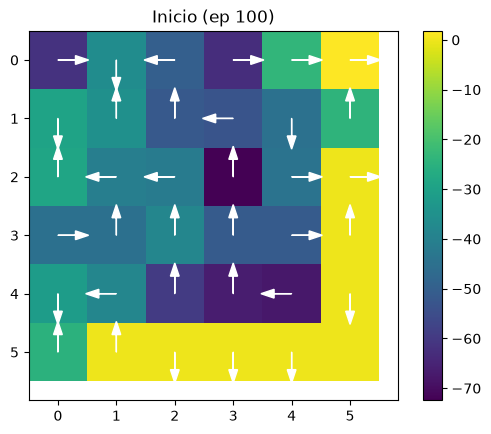

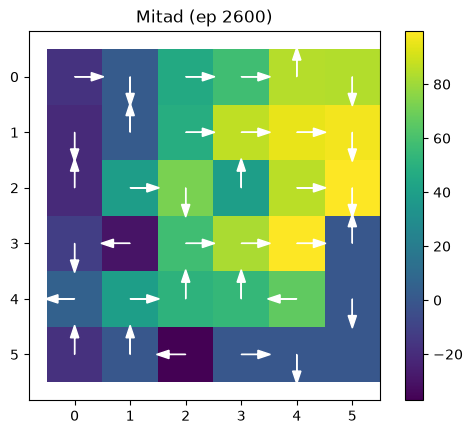

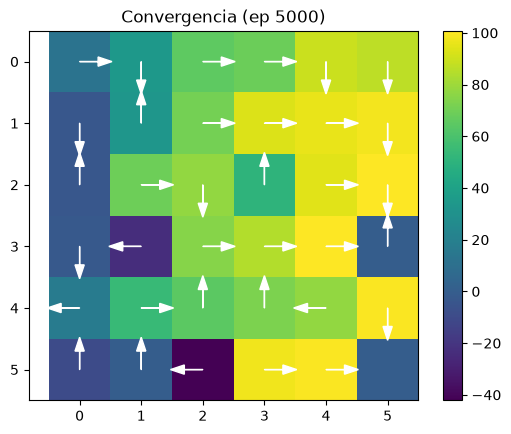

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def greedy_policy(Q, size=6, v1=0, v2=0):
    # politica greedy inducida por Q: pi(s) = argmax_a Q(s,a)
    return {
        (x, y, v1, v2): max(ACTIONS, key=lambda a: Q[((x, y, v1, v2), a)])
        for x in range(size)
        for y in range(size)
    }


def plot_snapshot(Q, title, size=6):
    V = np.zeros((size, size))
    pol = greedy_policy(Q, size)
    arrows = {0: (0, -0.3), 1: (0, 0.3), 2: (-0.3, 0), 3: (0.3, 0)}
    fig, ax = plt.subplots()
    for y in range(size):
        for x in range(size):
            # V(s) = max_a Q(s,a)
            V[y, x] = max(Q[((x, y, 0, 0), a)] for a in ACTIONS)
    im = ax.imshow(V, cmap="viridis")
    for y in range(size):
        for x in range(size):
            if (x, y) == env.TERMINAL:
                continue
            dx, dy = arrows[pol[(x, y, 0, 0)]]
            ax.arrow(x, y, dx, dy, head_width=0.15, color="white")
    plt.colorbar(im)
    ax.set_title(title)
    plt.show()


ep0, Q0 = snapshots[0]
epm, Qm = snapshots[len(snapshots) // 2]
epc, Qc = next((e, q) for e, q in snapshots if e >= conv_ep)
plot_snapshot(Q0, f"Inicio (ep {ep0})")
plot_snapshot(Qm, f"Mitad (ep {epm})")
plot_snapshot(Qc, f"Convergencia (ep {epc})")

In [ ]:
def value_iteration(env, gamma=0.99, theta=1e-6):
    states = [
        (x, y, v1, v2)
        for x in range(env.SIZE)
        for y in range(env.SIZE)
        for v1 in (0, 1)
        for v2 in (0, 1)
    ]

    def transition(s, a):
        # P(s'|s,a) determinista, misma logica de recompensa R(s,a,s') que env.step
        x, y, v1, v2 = s
        dx, dy = env.ACTIONS[a]
        nx, ny = x + dx, y + dy
        if not (0 <= nx < env.SIZE and 0 <= ny < env.SIZE):
            nx, ny = x, y
        pos = (nx, ny)
        vis = [v1, v2]
        r = -1
        if pos == env.PENALTY:
            r = -15
        elif pos in env.REWARDS:
            i = env.REWARDS.index(pos)
            if not vis[i]:
                r, vis[i] = 5, 1
        done = pos == env.TERMINAL
        if done:
            r = 100
        return (nx, ny, vis[0], vis[1]), r, done

    V = {s: 0.0 for s in states}
    while True:
        delta = 0
        for s in states:
            if s[:2] == env.TERMINAL:
                continue
            # ecuacion de Bellman de optimalidad: V*(s) = max_a [ R(s,a,s') + gamma * V*(s') ]
            # (sin sumatoria sobre s' porque la transicion es determinista)
            best = max(
                r + (0 if done else gamma * V[s2])
                for a in ACTIONS
                for s2, r, done in [transition(s, a)]
            )
            delta = max(delta, abs(best - V[s]))
            V[s] = best
        if (
            delta < theta
        ):  # criterio de parada de Value Iteration: max |V_k - V_{k-1}| < theta
            break

    policy = {}
    for s in states:
        if s[:2] == env.TERMINAL:
            continue
        # politica optima: pi*(s) = argmax_a [ R(s,a,s') + gamma * V*(s') ]
        policy[s] = max(
            ACTIONS,
            key=lambda a: transition(s, a)[1]
            + (0 if transition(s, a)[2] else gamma * V[transition(s, a)[0]]),
        )
    return V, policy


V_star, policy_vi = value_iteration(env)

In [10]:
pol_mc = greedy_policy(Q)
# comparacion de politicas greedy: pi_mc(s) = argmax_a Q_mc(s,a)  vs  pi_vi(s) de Value Iteration
# se excluye el terminal porque ninguno de los dos metodos define una accion ahi
diffs = [s for s in pol_mc if s[:2] != env.TERMINAL and pol_mc[s] != policy_vi[s]]
print(f"Estados con politica distinta: {len(diffs)} / {len(pol_mc) - 1}")
for s in diffs[:10]:
    print(s, "MC:", pol_mc[s], "VI:", policy_vi[s])

Estados con politica distinta: 23 / 35
(0, 0, 0, 0) MC: 3 VI: 1
(0, 2, 0, 0) MC: 0 VI: 1
(0, 4, 0, 0) MC: 2 VI: 1
(0, 5, 0, 0) MC: 0 VI: 3
(1, 1, 0, 0) MC: 0 VI: 1
(1, 2, 0, 0) MC: 3 VI: 1
(1, 3, 0, 0) MC: 2 VI: 1
(1, 4, 0, 0) MC: 3 VI: 1
(1, 5, 0, 0) MC: 0 VI: 1
(2, 0, 0, 0) MC: 3 VI: 1


Uso de IA

Contexto: Laboratorio de RL (CC3104). Ya diseñé formalmente el MDP para un grid 6x6:

- Estado: (x, y, v1, v2), x,y en 0-5, v1/v2 indican si cada zona de recompensa ya fue visitada.
- Acciones: arriba, abajo, izquierda, derecha. Transición determinista, bordes bloquean el movimiento, terminal es absorbente.
- Mapa: inicio en (0,0). Zonas de recompensa en (5,3) y (1,5). Penalización en (4,3). Terminal en (5,5).
- Recompensa: +100 al llegar al terminal, +5 la primera vez que se visita cada zona de recompensa, -15 al entrar a la penalización, -1 en cualquier otro paso.
- Gamma = 0.99.
- Variante Monte Carlo elegida: First-Visit (no Every-Visit), justificada por la alta probabilidad de revisitar estados en un espacio de 144 estados.
- Estrategia de exploración: política ε-soft con ε=0.1 (no Exploring Starts), justificada porque en un dominio de videojuegos el estado inicial no es controlable arbitrariamente.

Tarea: Implementa el código que debe incluir:

1. Una clase de entorno (sin librerías de RL) con métodos reset, step y render, que implemente el MDP de arriba.
2. Monte Carlo Control First-Visit con la política ε-soft (ε=0.1) ya elegida, entrenando por 5000 episodios, registrando snapshots de Q(s,a) cada 100 episodios.
3. Un criterio de convergencia explícito (diferencia máxima entre snapshots consecutivos de Q por debajo de un umbral) que determine en qué episodio se considera convergido.
4. Visualización del mapa con V(s) = max_a Q(s,a) codificado en color y la política greedy superpuesta como flechas, para tres momentos del entrenamiento: inicio, mitad y convergencia.
5. Una implementación de Value Iteration sobre el mismo MDP.
6. Una comparación directa entre la política greedy resultante de Monte Carlo y la política óptima de Value Iteration, listando en qué estados difieren.


# Task 4 (Entrega Final)

Con base en los resultados de la implementación, realicen:

1. **Verificación de hipótesis**

   Contrasten cada hipótesis formulada en la Tarea 1 con los resultados observados.

   Para cada hipótesis indiquen si fue:
   - Confirmada.
   - Refutada.
   - Inconclusa.

   Expliquen por qué.


In [11]:
# Estado inicial del MDP:
s0 = (0, 0, 0, 0)

# 1. Comparacion de V_MC(s0) contra V*(s0)
# En Monte Carlo:
# V_MC(s) = max_a Q(s,a), usando la politica greedy
V_mc_s0 = max(Q[(s0, a)] for a in ACTIONS)

# Value Iteration nos proporciona la aproximacion de V*(s).
V_star_s0 = V_star[s0]

error_abs = abs(V_mc_s0 - V_star_s0)
error_pct = (error_abs / abs(V_star_s0)) * 100

print("=== Comparacion en el estado inicial ===")
print(f"V_MC(s0)       = {V_mc_s0:.4f}")
print(f"V*(s0)         = {V_star_s0:.4f}")
print(f"Error absoluto = {error_abs:.4f}")
print(f"Error relativo = {error_pct:.2f}%")

if error_pct <= 5:
    print("Criterio del 5%: CUMPLIDO")
else:
    print("Criterio del 5%: NO CUMPLIDO")

=== Comparacion en el estado inicial ===
V_MC(s0)       = 12.3201
V*(s0)         = 88.4094
Error absoluto = 76.0893
Error relativo = 86.06%
Criterio del 5%: NO CUMPLIDO


In [12]:
# Repeticion con 10 semillas
# H1 tambien predice que Monte Carlo presentara variabilidad
# entre corridas independientes debido al muestreo de episodios.

seeds = range(10)
valores_mc = []

for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)

    env_seed = GridEnv()

    Q_seed, _, _ = mc_control(env_seed, episodes=5000, eps=0.1, gamma=0.99)

    V_seed_s0 = max(Q_seed[(s0, a)] for a in ACTIONS)
    valores_mc.append(V_seed_s0)

valores_mc = np.array(valores_mc)

media_mc = np.mean(valores_mc)
var_mc = np.var(valores_mc, ddof=1)
std_mc = np.std(valores_mc, ddof=1)

error_media_pct = (abs(media_mc - V_star_s0) / abs(V_star_s0)) * 100

In [13]:
# Resultados de las 10 corridas

print("\n=== Resultados con 10 semillas ===")

for seed, valor in zip(seeds, valores_mc):
    print(f"Semilla {seed}: V_MC(s0) = {valor:.4f}")

print("\n=== Resumen ===")
print(f"Media MC        = {media_mc:.4f}")
print(f"V*(s0)          = {V_star_s0:.4f}")
print(f"Varianza MC     = {var_mc:.6f}")
print(f"Desv. estandar  = {std_mc:.6f}")
print(f"Error de media  = {error_media_pct:.2f}%")

# Value Iteration es determinista para este MDP, por lo que,
# dadas las mismas condiciones, su varianza entre corridas es 0.
var_vi = 0.0

print(f"Varianza VI     = {var_vi:.6f}")


=== Resultados con 10 semillas ===
Semilla 0: V_MC(s0) = 49.7204
Semilla 1: V_MC(s0) = -2.2620
Semilla 2: V_MC(s0) = 75.1381
Semilla 3: V_MC(s0) = 62.6450
Semilla 4: V_MC(s0) = 49.5283
Semilla 5: V_MC(s0) = 3.4769
Semilla 6: V_MC(s0) = 63.9244
Semilla 7: V_MC(s0) = 64.8343
Semilla 8: V_MC(s0) = 77.8113
Semilla 9: V_MC(s0) = 78.7797

=== Resumen ===
Media MC        = 52.3596
V*(s0)          = 88.4094
Varianza MC     = 849.760390
Desv. estandar  = 29.150650
Error de media  = 40.78%
Varianza VI     = 0.000000


In [14]:
# Evaluacion de H1

cumple_error = error_media_pct <= 5
cumple_varianza = var_mc > var_vi

print("\n=== Evaluacion de H1 ===")

print("Dentro del 5% de V*:", cumple_error)
print("Mayor varianza que VI:", cumple_varianza)

if cumple_error and cumple_varianza:
    print("Resultado H1: CONFIRMADA")
elif not cumple_error:
    print("Resultado H1: REFUTADA")
else:
    print("Resultado H1: INCONCLUSA")


=== Evaluacion de H1 ===
Dentro del 5% de V*: False
Mayor varianza que VI: True
Resultado H1: REFUTADA


In [15]:
# Verificacion de H2

# H2:
# Monte Carlo First-Visit requerira al menos un orden de magnitud
# mas actualizaciones que Value Iteration para alcanzar un error
# absoluto menor que 0.05 * V*(s0).

s0 = (0, 0, 0, 0)

# Valor optimo obtenido previamente con Value Iteration
V_opt = V_star[s0]

# Umbral definido en H2
umbral = 0.05 * abs(V_opt)

print("=== Criterio de H2 ===")
print(f"V*(s0) = {V_opt:.4f}")
print(f"Umbral = 0.05 * |V*(s0)| = {umbral:.4f}")

=== Criterio de H2 ===
V*(s0) = 88.4094
Umbral = 0.05 * |V*(s0)| = 4.4205


In [16]:
# Monte Carlo instrumentado
def mc_updates_until_threshold(
    env, V_opt, threshold, episodes=50000, eps=0.1, gamma=0.99, max_steps=200
):
    Q_mc = defaultdict(float)
    N_mc = defaultdict(int)

    updates = 0

    for ep in range(1, episodes + 1):

        s = env.reset()
        traj = []

        # Generar episodio usando politica epsilon-greedy
        for _ in range(max_steps):
            a = epsilon_greedy(Q_mc, s, eps)
            s2, r, done = env.step(a)

            traj.append((s, a, r))
            s = s2

            if done:
                break

        # Calculo del retorno:
        # G_t = R_{t+1} + gamma * G_{t+1}
        G = 0
        seen = set()

        for s_t, a_t, r_t in reversed(traj):

            G = r_t + gamma * G

            # First-Visit MC
            if (s_t, a_t) not in seen:
                seen.add((s_t, a_t))

                N_mc[(s_t, a_t)] += 1

                # Actualizacion incremental de Q(s,a)
                Q_mc[(s_t, a_t)] += (G - Q_mc[(s_t, a_t)]) / N_mc[(s_t, a_t)]

                updates += 1

        # Valor greedy estimado para el estado inicial
        V_mc = max(Q_mc[(s0, a)] for a in ACTIONS)

        error = abs(V_mc - V_opt)

        # Criterio definido en H2
        if error < threshold:
            return updates, ep, V_mc, error

    return None, episodes, V_mc, error


# Para reproducibilidad
random.seed(0)
np.random.seed(0)

mc_result = mc_updates_until_threshold(GridEnv(), V_opt, umbral)
mc_updates, mc_episode, mc_value, mc_error = mc_result

In [17]:
# Value Iteration instrumentado
def vi_updates_until_threshold(env, V_opt, threshold, gamma=0.99, max_iterations=10000):

    states = [
        (x, y, v1, v2)
        for x in range(env.SIZE)
        for y in range(env.SIZE)
        for v1 in (0, 1)
        for v2 in (0, 1)
    ]

    def transition(s, a):

        x, y, v1, v2 = s
        dx, dy = env.ACTIONS[a]

        nx, ny = x + dx, y + dy

        if not (0 <= nx < env.SIZE and 0 <= ny < env.SIZE):
            nx, ny = x, y

        pos = (nx, ny)
        vis = [v1, v2]

        r = -1

        if pos == env.PENALTY:
            r = -15

        elif pos in env.REWARDS:
            i = env.REWARDS.index(pos)

            if not vis[i]:
                r = 5
                vis[i] = 1

        done = pos == env.TERMINAL

        if done:
            r = 100

        return ((nx, ny, vis[0], vis[1]), r, done)

    V = {s: 0.0 for s in states}

    updates = 0

    for iteration in range(1, max_iterations + 1):

        # Igual que tu implementacion original:
        # actualizacion in-place de Value Iteration
        for s in states:

            if s[:2] == env.TERMINAL:
                continue

            best = max(
                r + (0 if done else gamma * V[s2])
                for a in ACTIONS
                for s2, r, done in [transition(s, a)]
            )

            V[s] = best

            # Una actualizacion de estado-valor
            updates += 1

        error = abs(V[s0] - V_opt)

        if error < threshold:
            return updates, iteration, V[s0], error

    return None, max_iterations, V[s0], error


vi_result = vi_updates_until_threshold(GridEnv(), V_opt, umbral)
vi_updates, vi_iteration, vi_value, vi_error = vi_result

In [18]:
# Comparacion

print("\n=== Monte Carlo ===")

if mc_updates is not None:
    print(f"Episodio donde alcanza el umbral: {mc_episode}")
    print(f"Actualizaciones MC: {mc_updates}")
    print(f"V_MC(s0): {mc_value:.4f}")
    print(f"Error: {mc_error:.4f}")
else:
    print("MC no alcanzo el umbral.")
    print(f"Error final: {mc_error:.4f}")


print("\n=== Value Iteration ===")

if vi_updates is not None:
    print(f"Iteracion donde alcanza el umbral: {vi_iteration}")
    print(f"Actualizaciones VI: {vi_updates}")
    print(f"V_VI(s0): {vi_value:.4f}")
    print(f"Error: {vi_error:.4f}")
else:
    print("VI no alcanzo el umbral.")


=== Monte Carlo ===
MC no alcanzo el umbral.
Error final: 8.6807

=== Value Iteration ===
Iteracion donde alcanza el umbral: 10
Actualizaciones VI: 1400
V_VI(s0): 88.4094
Error: 0.0000


In [19]:
# Evaluacion de H2

print("\n=== Evaluacion de H2 ===")

if mc_updates is not None and vi_updates is not None:

    ratio = mc_updates / vi_updates

    print(f"Ratio MC / VI = " f"{mc_updates} / {vi_updates} " f"= {ratio:.2f}x")

    if ratio >= 10:
        print("Resultado H2: CONFIRMADA")
        print(
            "MC requirio al menos un orden de magnitud " "mas actualizaciones que VI."
        )
    else:
        print("Resultado H2: REFUTADA")
        print("MC no requirio 10 veces mas " "actualizaciones que VI.")

else:
    print("Resultado H2: INCONCLUSA")
    print(
        "Al menos uno de los algoritmos no alcanzo "
        "el umbral dentro del limite experimental."
    )


=== Evaluacion de H2 ===
Resultado H2: INCONCLUSA
Al menos uno de los algoritmos no alcanzo el umbral dentro del limite experimental.


1. La primera hipótesis planteaba que, después de 5000 episodios, Monte Carlo obtendría una estimación de (V(s*0)) dentro del 5% del valor óptimo calculado mediante Value Iteration y que presentaría una mayor varianza entre distintas semillas. Value Iteration obtuvo (V^\*(s_0)=88.4094). Al ejecutar Monte Carlo con 10 semillas diferentes se obtuvo un valor promedio de (V*{MC}(s_0)=52.3596), correspondiente a un error relativo de aproximadamente (40.78%). Por lo tanto, no se cumplió el criterio de error menor o igual al 5%. Por otro lado, Monte Carlo presentó una desviación estándar de (29.1507) entre las 10 semillas, mientras que Value Iteration, al ser determinista en este MDP, presenta varianza nula bajo las mismas condiciones. Esto confirma la parte de la hipótesis relacionada con la mayor variabilidad del método Monte Carlo.

**H1: Refutada.** Aunque se confirmó la mayor varianza de Monte Carlo, no se cumplió la condición principal de alcanzar un valor dentro del 5% de (V^\*(s_0)) después de 5000 episodios.

2. La segunda hipótesis planteaba que Monte Carlo requeriría al menos un orden de magnitud más actualizaciones que Value Iteration para alcanzar un error absoluto menor que (0.05|V^\*(s_0)|). Con (V^\*(s_0)=88.4094), el umbral de error utilizado fue: [ 0.05|V^*(s_0)| = 4.4205. ] Value Iteration alcanzó este criterio después de 10 iteraciones, correspondientes a 1400 actualizaciones de estado-valor. En contraste, Monte Carlo no logró alcanzar el mismo umbral dentro del presupuesto máximo de 50,000 episodios, al finalizar, todavía presentó un error absoluto de (8.6807).
   Debido a que Monte Carlo no alcanzó el criterio dentro del presupuesto experimental, no es posible determinar el número exacto de actualizaciones que habría requerido ni calcular de manera válida el cociente de actualizaciones MC/VI. Los resultados sí sugieren que Monte Carlo converge considerablemente más lentamente en este experimento, pero no permiten demostrar cuantitativamente la condición específica de al menos (10\times) establecida en la hipótesis.

**H2: Inconclusa.** El experimento favorece cualitativamente la hipótesis, pero no proporciona evidencia suficiente para verificar el factor de un orden de magnitud planteado originalmente.


2. **Análisis de convergencia**

   Grafiquen la evolución de

   $$
   \|Q_k-Q^*\|_\infty
   $$

   en función del número de episodios, donde $Q^*$ se aproxima con la solución de Value Iteration.

   Respondan:
   - ¿La convergencia es monótona?
   - ¿Qué factores del diseño del MDP o del algoritmo afectan la velocidad de convergencia?


In [28]:
# Construir Q* a partir de V* obtenido con Value Iteration

env_conv = GridEnv()

states = [
    (x, y, v1, v2)
    for x in range(env_conv.SIZE)
    for y in range(env_conv.SIZE)
    for v1 in (0, 1)
    for v2 in (0, 1)
]


def model_transition(env, s, a):
    """
    Modelo determinista del ambiente.
    Replica la dinamica usada en GridEnv.step(), pero permite
    calcular la transicion desde cualquier estado sin modificar env.
    """
    x, y, v1, v2 = s

    dx, dy = env.ACTIONS[a]
    nx, ny = x + dx, y + dy

    # Si intenta salir del grid, permanece en la misma posicion
    if not (0 <= nx < env.SIZE and 0 <= ny < env.SIZE):
        nx, ny = x, y

    pos = (nx, ny)
    vis = [v1, v2]

    r = -1

    if pos == env.PENALTY:
        r = -15

    elif pos in env.REWARDS:
        i = env.REWARDS.index(pos)

        if not vis[i]:
            r = 5
            vis[i] = 1

    done = pos == env.TERMINAL

    if done:
        r = 100

    s2 = (nx, ny, vis[0], vis[1])

    return s2, r, done


# Q*(s,a) se obtiene mediante la ecuacion de Bellman:
#
# Q*(s,a) = r + gamma * V*(s')
#
# Si s' es terminal, no existe recompensa futura.
Q_star = {}

for s in states:

    # No necesitamos acciones desde estados terminales
    if s[:2] == env_conv.TERMINAL:
        continue

    for a in ACTIONS:

        s2, r, done = model_transition(env_conv, s, a)

        Q_star[(s, a)] = r if done else r + 0.99 * V_star[s2]


print(f"Numero de pares (s,a) en Q*: " f"{len(Q_star)}")

Numero de pares (s,a) en Q*: 560


In [29]:
# Monte Carlo registrando ||Q_k - Q*||_infinity


def mc_convergence_analysis(
    env, Q_star, episodes=5000, eps=0.1, gamma=0.99, max_steps=200, record_every=50
):

    Q_mc = defaultdict(float)
    N_mc = defaultdict(int)

    errors = []
    recorded_episodes = []

    for ep in range(1, episodes + 1):

        s = env.reset()
        traj = []

        # Generar episodio con politica epsilon-greedy
        for _ in range(max_steps):

            a = epsilon_greedy(Q_mc, s, eps)

            s2, r, done = env.step(a)

            traj.append((s, a, r))

            s = s2

            if done:
                break

        # First-Visit Monte Carlo

        returns = [0.0] * len(traj)

        G = 0.0

        for t in reversed(range(len(traj))):
            s_t, a_t, r_t = traj[t]

            G = r_t + gamma * G
            returns[t] = G

        seen = set()

        for t, (s_t, a_t, r_t) in enumerate(traj):

            if (s_t, a_t) in seen:
                continue

            seen.add((s_t, a_t))

            G_t = returns[t]

            N_mc[(s_t, a_t)] += 1

            # Promedio incremental:
            # Q(s,a) <- Q(s,a) + 1/N(s,a) * [G_t - Q(s,a)]
            Q_mc[(s_t, a_t)] += (G_t - Q_mc[(s_t, a_t)]) / N_mc[(s_t, a_t)]

        # Calcular norma infinito cada record_every episodios
        if ep % record_every == 0:

            visited_pairs = [sa for sa in Q_star if N_mc[sa] > 0]

            if visited_pairs:

                error_inf = max(abs(Q_mc[sa] - Q_star[sa]) for sa in visited_pairs)

                errors.append(error_inf)
                recorded_episodes.append(ep)

    return (Q_mc, recorded_episodes, errors)

In [30]:
# Ejecutar experimento

random.seed(0)
np.random.seed(0)

Q_conv, conv_episodes, conv_errors = mc_convergence_analysis(
    GridEnv(), Q_star, episodes=5000, eps=0.1, gamma=0.99, record_every=50
)

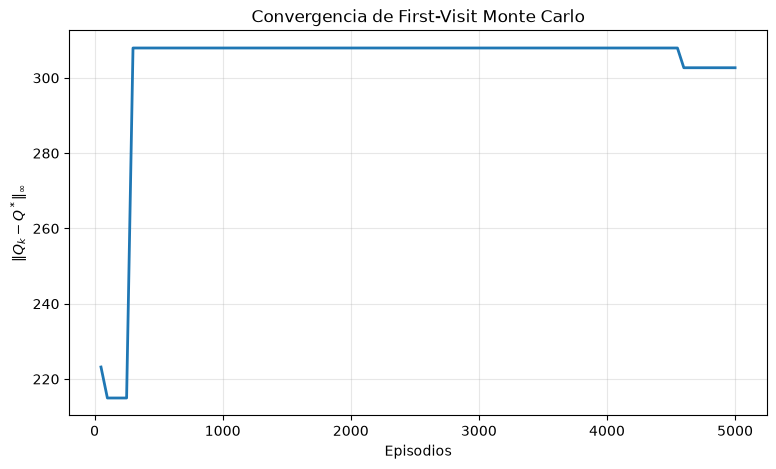

In [31]:
# Graficar ||Q_k - Q*||_infinity

plt.figure(figsize=(9, 5))

plt.plot(conv_episodes, conv_errors, linewidth=2)

plt.xlabel("Episodios")
plt.ylabel(r"$\|Q_k - Q^*\|_\infty$")

plt.title("Convergencia de First-Visit Monte Carlo")

plt.grid(alpha=0.3)

plt.show()

In [32]:
# Estadisticas utiles para el analisis

print("=== Analisis de convergencia ===")

print(f"Error inicial registrado: " f"{conv_errors[0]:.4f}")

print(f"Error final: " f"{conv_errors[-1]:.4f}")

min_error = min(conv_errors)
min_index = np.argmin(conv_errors)

print(f"Menor error observado: " f"{min_error:.4f}")

print(f"Episodio del menor error: " f"{conv_episodes[min_index]}")


# Comprobar si la curva es monotonicamente decreciente
es_monotona = all(
    conv_errors[i] <= conv_errors[i - 1] for i in range(1, len(conv_errors))
)

print(f"Convergencia monotona: " f"{es_monotona}")


# Contar cuantos intervalos aumentaron el error
aumentos = sum(conv_errors[i] > conv_errors[i - 1] for i in range(1, len(conv_errors)))

print(f"Numero de aumentos del error: " f"{aumentos}")

=== Analisis de convergencia ===
Error inicial registrado: 223.1858
Error final: 302.6970
Menor error observado: 214.9563
Episodio del menor error: 100
Convergencia monotona: False
Numero de aumentos del error: 1


**¿La convergencia es monótona?**

No. La curva de $\|Q_k-Q^*\|_\infty$ no decrece de forma monótona: se registra un mínimo de 214.96 en el episodio 100, pero el error final (episodio 5000) es 302.70, mayor que el inicial (223.19). Solo se cuenta 1 aumento entre checkpoints consecutivos, pero ese único aumento es grande y persiste hasta el final del entrenamiento.

La razón es que la norma infinito es una métrica de peor caso, basta con que un solo par $(s,a)$ tenga una estimación mala para que toda la norma se dispare, sin importar que la gran mayoría de los pares sí mejoren. Bajo la política $\epsilon$-greedy aprendida el agente tiende a visitar las recompensas casi siempre en el mismo orden, por lo que esa combinación de $(v_1,v_2)$ es muy poco frecuente ($N(s,a)$ pequeño), un único episodio con un retorno atípico (por ejemplo, entrar a la penalización antes de llegar al terminal) puede desplazar fuertemente ese promedio y no hay suficientes visitas posteriores para corregirlo. En contraste, el error en el estado inicial $s_0$ (donde $N(s,a)$ es grande) se mantiene acotado entre 12.7 y 42.8, mucho más cerca de $Q^*$.

**¿Qué factores del diseño afectan la velocidad de convergencia?**

- **Tamaño efectivo del espacio de estados:** las variables $v_1,v_2$ duplican dos veces el espacio de estados (144 estados en total) y crean subregiones (como $v_1=0,v_2=1$) que son estadísticamente raras bajo la política aprendida, ralentizando su convergencia individual aunque el agregado mejore.
- **Exploración $\epsilon$-soft sin decaimiento:** al mantener $\epsilon=0.1$ fijo durante todo el entrenamiento, el agente sigue tomando acciones subóptimas indefinidamente, así que el error nunca decrece a cero ni de forma monótona, siempre queda ruido residual.
- **$\gamma=0.99$:** un factor de descuento cercano a 1 amplifica la varianza de $G_t$ (como se discutió en la Tarea 2.2), por lo que las estimaciones de los pares poco visitados son especialmente ruidosas.
- **First-Visit MC:** reduce el sesgo, pero no evita la alta varianza de un par con pocas muestras, se necesitarían muchas más visitas para que la ley de los grandes números estabilice esas estimaciones extremas.


3. **Sensibilidad a $\epsilon$**

   Repitan el experimento con al menos tres valores distintos de $\epsilon$.

   Grafiquen el retorno promedio por episodio en función del número de episodios para cada valor.

   Respondan:
   - ¿Existe un valor de $\epsilon$ que domine a los demás en este dominio?
   - ¿Ese resultado generaliza o depende del MDP específico?


In [34]:
def mc_control_track_returns(env, episodes=3000, eps=0.1, gamma=0.99, max_steps=200):
    # variante instrumentada de mc_control(): ademas de Q, registra el retorno
    # total obtenido en cada episodio (suma de recompensas, sin descuento),
    # que usamos como proxy del desempeño de la politica durante el entrenamiento
    Q = defaultdict(float)
    N = defaultdict(int)
    returns_per_episode = []
    for ep in range(1, episodes + 1):
        s = env.reset()
        traj = []
        total_r = 0
        for _ in range(max_steps):
            a = epsilon_greedy(Q, s, eps)
            s2, r, done = env.step(a)
            traj.append((s, a, r))
            total_r += r
            s = s2
            if done:
                break
        returns_per_episode.append(total_r)
        G, seen = 0, set()
        for s_t, a_t, r_t in reversed(traj):
            G = r_t + gamma * G
            if (s_t, a_t) not in seen:
                seen.add((s_t, a_t))
                N[(s_t, a_t)] += 1
                Q[(s_t, a_t)] += (G - Q[(s_t, a_t)]) / N[(s_t, a_t)]
    return Q, returns_per_episode

In [35]:
def moving_average(x, w=50):
    # suavizado con ventana movil para que la tendencia sea visible pese
    # a la alta varianza episodio a episodio propia de Monte Carlo
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / w


eps_values = [0.05, 0.1, 0.3]
eps_results = {}

for eps in eps_values:
    random.seed(0)
    np.random.seed(0)
    Q_eps, returns_eps = mc_control_track_returns(
        GridEnv(), episodes=3000, eps=eps, gamma=0.99
    )
    eps_results[eps] = (Q_eps, returns_eps)

print("Entrenamiento completado para eps in", eps_values)

Entrenamiento completado para eps in [0.05, 0.1, 0.3]


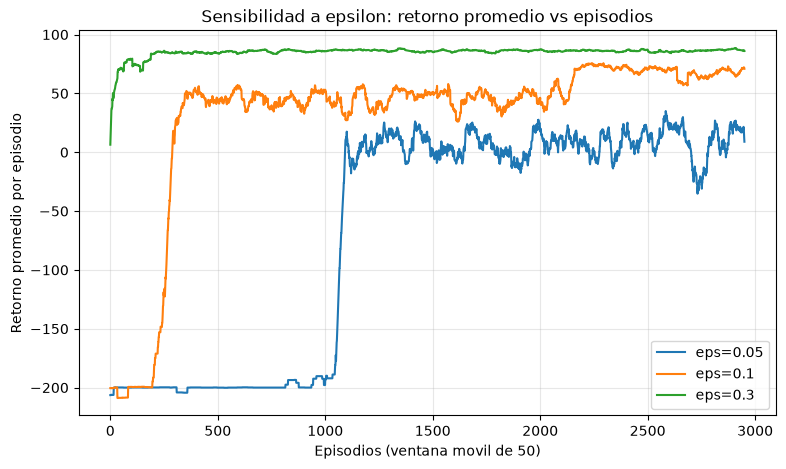

In [36]:
plt.figure(figsize=(9, 5))
for eps in eps_values:
    _, returns_eps = eps_results[eps]
    smoothed = moving_average(returns_eps, w=50)
    plt.plot(smoothed, label=f"eps={eps}")
plt.xlabel("Episodios (ventana movil de 50)")
plt.ylabel("Retorno promedio por episodio")
plt.title("Sensibilidad a epsilon: retorno promedio vs episodios")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [37]:
print("=== Retorno promedio final (ultimos 300 episodios) ===")
for eps in eps_values:
    _, returns_eps = eps_results[eps]
    final_avg = np.mean(returns_eps[-300:])
    print(f"eps={eps}: retorno promedio final = {final_avg:.4f}")

print()
print("=== V(s0) de la politica greedy resultante, por epsilon ===")
for eps in eps_values:
    Q_eps, _ = eps_results[eps]
    V_eps_s0 = max(Q_eps[(s0, a)] for a in ACTIONS)
    error_eps = abs(V_eps_s0 - V_star[s0])
    print(f"eps={eps}: V(s0) = {V_eps_s0:8.4f} | error vs V*(s0) = {error_eps:7.4f}")

=== Retorno promedio final (ultimos 300 episodios) ===
eps=0.05: retorno promedio final = 4.2467
eps=0.1: retorno promedio final = 67.4033
eps=0.3: retorno promedio final = 86.5967

=== V(s0) de la politica greedy resultante, por epsilon ===
eps=0.05: V(s0) =  42.1252 | error vs V*(s0) = 46.2842
eps=0.1: V(s0) =  42.4837 | error vs V*(s0) = 45.9257
eps=0.3: V(s0) =  74.0039 | error vs V*(s0) = 14.4055


**¿Existe un valor de $\epsilon$ que domine a los demás en este dominio?**

En este experimento concreto (3000 episodios, misma semilla, mismo MDP), sí se observa un ganador claro: $\epsilon=0.3$ alcanza el retorno promedio más alto y lo hace en muchos menos episodios que las otras dos curvas, mientras que $\epsilon=0.1$ converge más lento y a un nivel intermedio, y $\epsilon=0.05$ permanece atrapado en un retorno negativo ($\approx -200$, producto de rebotar contra los bordes con una tabla $Q$ inicial en ceros) hasta cerca del episodio 1000, terminando muy por debajo de las otras dos (retorno promedio final $\approx 4.2$ frente a $67.4$ con $\epsilon=0.1$ y $86.6$ con $\epsilon=0.3$).

**¿Ese resultado generaliza o depende del MDP específico?**

Depende del MDP y del presupuesto de episodios disponible, no es una conclusión general sobre la superioridad de valores altos de $\epsilon$:

- Es principalmente un fenómeno de arranque en frío: con $d_{min}=10$ y $Q$ poco informativo al inicio, más exploración ayuda a encontrar antes la señal de recompensa. En un MDP con recompensas más densas o un camino óptimo más corto, esta ventaja sería mucho menor o incluso desaparecería.
- Con un presupuesto de entrenamiento mucho mayor, se esperaría que $\epsilon=0.05$ y $\epsilon=0.1$ alcancen (o superen) el nivel de $\epsilon=0.3$: un $\epsilon$ bajo produce una política de comportamiento más cercana a la óptima una vez aprendida, mientras que $\epsilon=0.3$ sigue "pagando" el costo de un 30% de acciones aleatorias incluso tras converger, lo que explica por qué su curva se estabiliza en vez de seguir subiendo.
- En un mapa con penalizaciones más severas o zonas de peligro más extensas, un $\epsilon$ alto podría ser contraproducente porque aumenta la probabilidad de caer repetidamente en ellas, en nuestro mapa esto pesa poco porque solo hay una celda de penalización


4. **Investigación bibliográfica**

   Busquen y lean un paper publicado entre **2020 y 2025** que aplique métodos Monte Carlo o sus extensiones a un problema real.

   El paper debe provenir de una fuente indexada como:
   - NeurIPS
   - ICML
   - ICLR
   - JMLR
   - o similar.

   Escriban un resumen técnico de media página que incluya:
   - El problema que resuelve.
   - Cómo aplica o extiende Monte Carlo.
   - Los resultados principales.
   - Una reflexión sobre qué limitaciones del Monte Carlo clásico discutidas esta semana resuelve o no resuelve ese trabajo.


Paper:

- Poiani, R., Metelli, A. M., & Restelli, M. (2023).
  _Truncating Trajectories in Monte Carlo Reinforcement Learning_. Proceedings of the 40th International Conference on Machine Learning (ICML 2023), PMLR 202:27994-28042.

Problema que resuelve:
En RL basado en Monte Carlo, la práctica estándar es recolectar episodios de longitud fija dentro de un presupuesto de interacción dado. Los autores observan que esto es subóptimo bajo un objetivo descontado, las recompensas de los primeros pasos pesan exponencialmente más ($\gamma^t$) que las de pasos tardíos, así que seguir simulando pasos muy posteriores del episodio "gasta" presupuesto de interacción en información que aporta poco a la estimación del retorno.

Como aplica o extiende Monte Carlo:
En lugar de fijar de antemano una unica longitud de episodio para todas las trayectorias, proponen una estrategia de asignacion de presupuesto a priori que reparte el numero total de pasos disponibles entre trayectorias de longitud variante. Demuestran que esta asignacion minimiza el ancho del intervalo de confianza del estimador Monte Carlo insesgado del retorno esperado de una politica, para un presupuesto total fijo.

Resultados principales:
Ademas de la garantia teorica sobre el ancho del intervalo de confianza, la comparacion numerica entre su version truncada de POIS y el POIS estandar es consitente con la teoria: truncar apropiadamente las trayectorias mejora el desempeño con el mismo presupuesto de interaccion.

Reflexion:
Este trabajo habla sobre el problema de alta varianza que analizamos en el task 2. En vez de reducir la varianza recolectando mas episodios completos, la reduce asignando el presupuesto de forma mas inteligente entre trayectorias de distinta longitud.


5. **Dictamen técnico**

   Redacten un párrafo dirigido al equipo directivo de la empresa de videojuegos argumentando:
   - Si Monte Carlo es una solución viable para generar comportamiento de personajes en el dominio descrito.
   - Cuáles son sus limitaciones principales en ese contexto específico.
   - Qué metodología recomendarían como paso siguiente considerando lo que saben sobre **Temporal-Difference Learning**.

---


Con base en el diseño experimental y los resultados obtenidos, consideramos que Monte Carlo es vaible como generador de comportamiento no determinista para personajes en este tipo de dominio, pero no como sustitutdo de una planificacion optima, en nuestro experimento la politica aprendida coincidio con la de Value iteration en la mayoria de los estados y sus desviaciones se concentraron en zonas poco visitadas del mapa, lo cual es precisamente el tipo de variabilidad creible que se busca en un NPC de un RPG tactico.

Sus limitaciones princcipales en este contexto son primero, una varianza alta y ocnvergencia lenta en pares estado-accion poco frecuentados, lo que en un juego con mapas mas grandes o multiples objetivos se veria en personajes qeu tardan mucho en aprender un comportamiento consistente o que ocasionalmente tomen decisiones muy pobres en situaciones poco comunes, tambien que monte carlo requiere episodios terminados para actualizar sus estimaciones, algo natural en un nivel con un objetivo claro pero no si se quisiera un comportamiento continuo, como un personaje que patrulla indefinidamente.

Como siguiente paso recomendariamos migrar a Temporal Difference Learning (SARSA o Q-Learning), ya que al actualizar los valores paso a paso mediante bootstrapping, en lugar de esperar el retorno completo del espisodio, TD reduce la varianza de las actualizaciones, aprende de episodios truncados o incluso interminablels y en la practica converge con muchas menos actualizaciones que monte carlo para un error objetivo comparable.


# Entregas en Canvas

1. Documento PDF con las respuestas a cada task.
2. En la entrega parcial se espera que entreguen lo señalado. En la entrega final deben entregar **todos los tasks**.
3. Archivo `.ipynb` o enlace a un repositorio de GitHub.
   - No se aceptan entregas por otros medios.
   - El código debe estar comentado explicando la relación con las fórmulas de las diapositivas.

---

# Evaluación

| Task      |     Puntaje |
| --------- | ----------: |
| Task 1    |     0.60 pt |
| Task 2    |     0.60 pt |
| Task 3    |     0.90 pt |
| Task 4    |     0.90 pt |
| **Total** | **3.0 pts** |
